In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df1 = pd.read_csv('/content/e_commerce_raw.csv')
df2 = pd.read_csv('/content/customer_reference.csv')

# **Task 1 — Data Profiling**

**แสดงจำนวนแถว/คอลัมน์ ชนิดข้อมูล และตัวอย่างอย่างน้อย 5 แถว**

In [37]:
print('จำนวนแถวที่1:', df1.shape)
print('จำนวนแถวที่2:', df2.shape)

จำนวนแถวที่1: (630, 16)
จำนวนแถวที่2: (167, 4)


In [38]:
print("ตารางที่ 1")
df1.head()

ตารางที่ 1


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


In [39]:
print("ตารางที่ 2")
df2.head()

ตารางที่ 2


,Customer_ID,Customer_Name,Customer_Email,Province
0,C0001,Tee Saelim,tee.saelim1@example.com,Bangkok
1,C0002,Mint Thongdee,mint.thongdee2@example.com,Rayong
2,C0004,Tee Dechawat,tee.dechawat4@example.com,Bangkok
3,C0005,Ploy Chaiyo,ploy.chaiyo5@example.com,Bangkok
4,C0006,Pim Khamdee,pim.khamdee6@example.com,Nakhon Ratchasima


**สรุป Missing Values รายคอลัมน์ จำนวน Exact Duplicates และสถิติของตัวแปรตัวเลข**

In [40]:
df1.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
Customer_Name,0
Customer_Email,50
Gender,0
Province,12
Order_Date,0
Load_Timestamp,0
Product_Category,0
Quantity,0


In [41]:
df2.isnull().sum()

,0
Customer_ID,0
Customer_Name,0
Customer_Email,0
Province,3


In [42]:
df1.duplicated().sum()

np.int64(18)

In [43]:
df2.duplicated().sum()

np.int64(0)

In [44]:
df1.describe()

,Quantity,Unit_Price,Discount_Rate,Transaction_Amount
count,630.000000,630.000000,630.000000,630.000000
mean,3.660317,227.080365,0.061746,6092.293000
std,4.184784,126.984729,0.066935,66925.290163
min,-3.000000,37.360000,0.000000,-500.000000
25%,2.000000,137.095000,0.000000,316.190000
50%,3.000000,198.935000,0.050000,579.600000
75%,5.000000,298.615000,0.100000,1037.892500
max,99.000000,779.430000,0.200000,999999.000000


In [45]:
df2.describe()

,Customer_ID,Customer_Name,Customer_Email,Province
count,167,167,167,164
unique,167,119,167,8
top,C0001,Korn Srisawat,tee.saelim1@example.com,Nakhon Ratchasima
freq,1,4,1,28


ระบุปัญหาอย่างน้อย 5 ปัญหา และจับคู่กับ Data Quality อย่างน้อย 3 มิติ

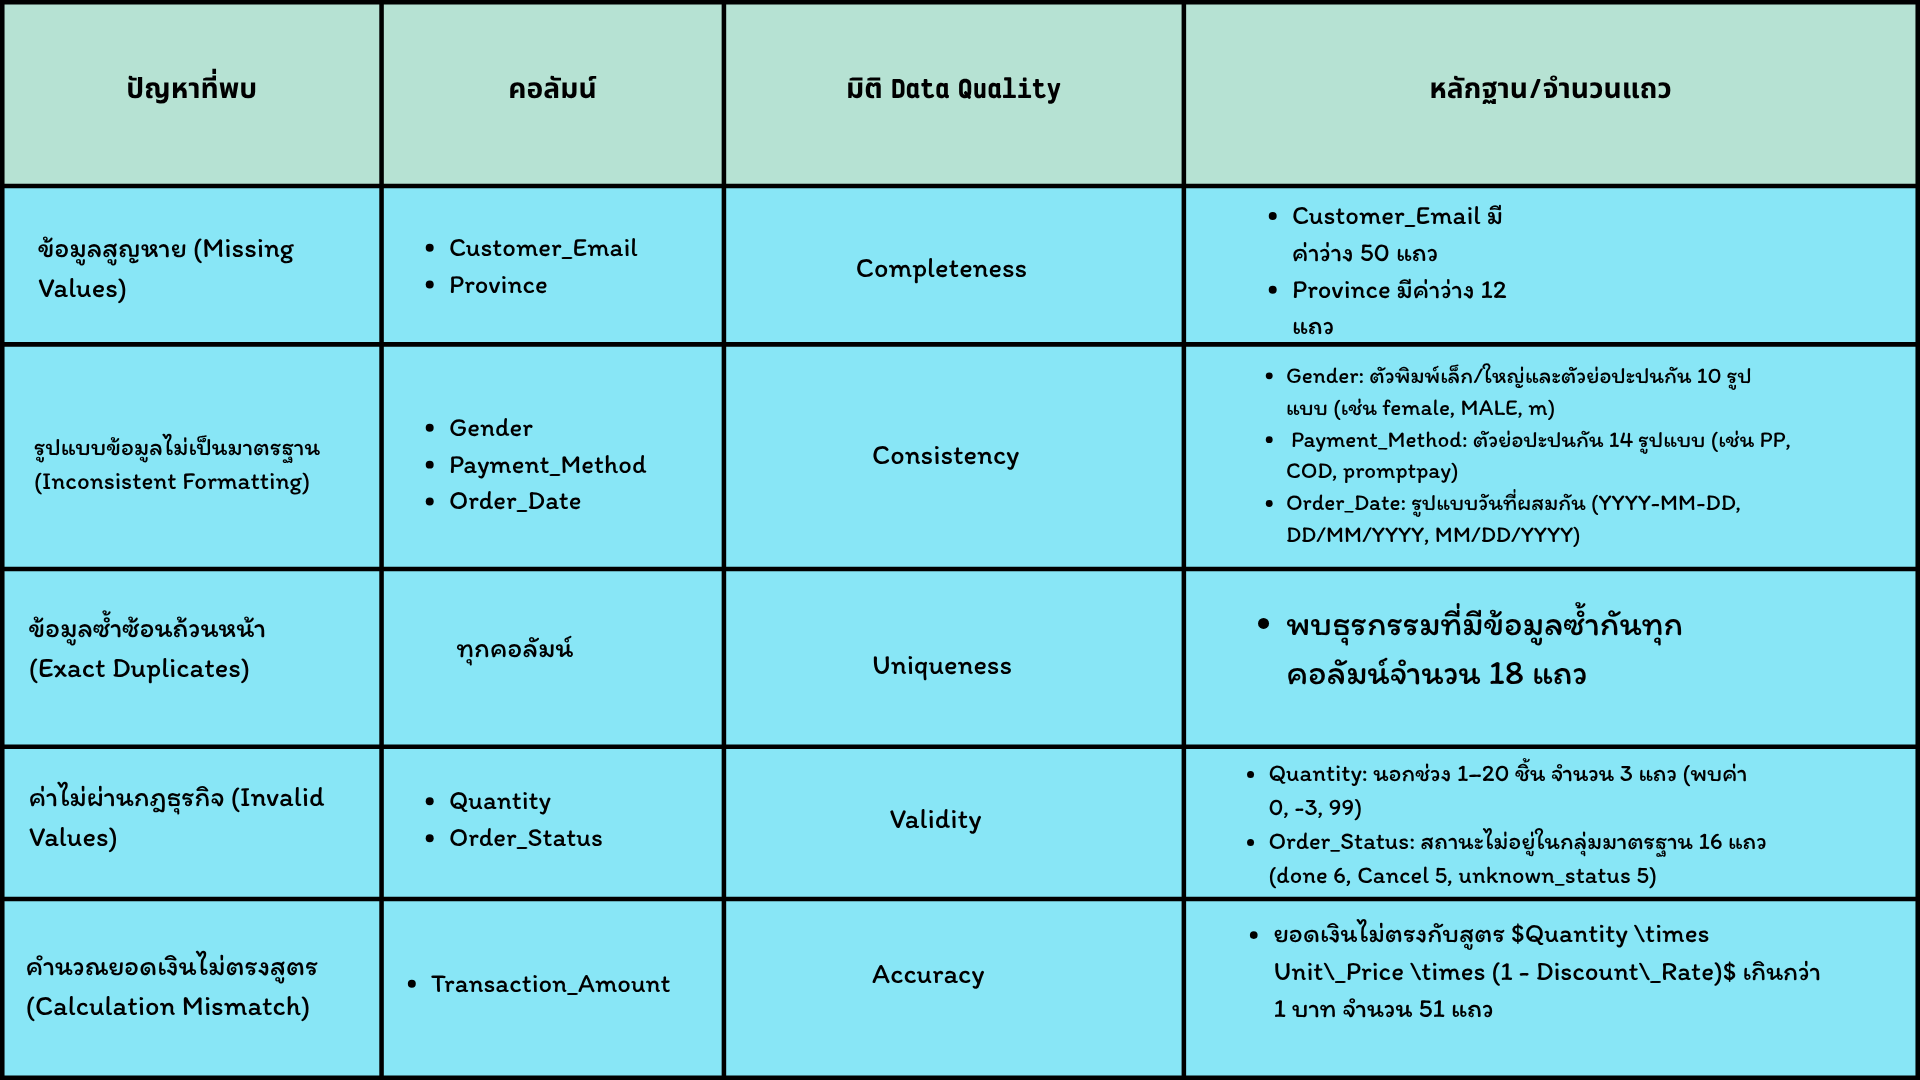

# **Task 2 — Completeness**

**สร้าง Customer_Email_Was_Missing และ Province_Was_Missing ก่อนแก้ข้อมูล**

In [46]:
df1['Customer_Email_Was_Missing'] = df1['Customer_Email'].isna()
df1['Province_Was_Missing'] = df1['Province'].isna()

**ห้าม drop แถวเพียงเพราะ Customer_Email หาย เพราะจะทำให้ Fact และยอดขายสูญหาย**

**เติมอีเมลแบบ traceable เช่น unknown_<Customer_ID>@unknown.local และเติม Province เป็น
Unknown**

In [47]:
# 3. เติมอีเมลแบบ traceable และเติม Province เป็น Unknown
df1['Customer_Email'] = df1.apply(
    lambda row: f"unknown_{row['Customer_ID']}@unknown.local"
    if pd.isna(row['Customer_Email'])
    else row['Customer_Email'],
    axis=1
)

df1['Province'] = df1['Province'].fillna('Unknown')

อธิบายเหตุผลว่าทำไม Mean Imputation ถึงใช้กับอีเมลไม่ได้

1.ชนิดข้อมูลไม่สอดคล้อง

2.ละเมิดหลักความเป็นเอกลักษณ์

3.รูปแบบข้อมูลผิดมาตรฐาน

# **Task 3 — Consistency**

**แปลง Gender ให้เหลือ M, F, Unknown**

In [48]:
gender_map = {
    'm': 'M', 'male': 'M', 'M': 'M', 'MALE': 'M', 'Male': 'M',
    'f': 'F', 'female': 'F', 'F': 'F', 'FEMALE': 'F', 'Female': 'F'
}
df1['Gender'] = df1['Gender'].astype(str).str.strip().map(gender_map).fillna('Unknown')

**แปลง Payment_Method ให้เหลือ Credit Card, PromptPay,Cash on Delivery, Bank Transfer, Unknown**

In [49]:
payment_map = {
    'credit card': 'Credit Card', 'cc': 'Credit Card', 'card': 'Credit Card',
    'promptpay': 'PromptPay', 'pp': 'PromptPay', 'prompt pay': 'PromptPay',
    'cash on delivery': 'Cash on Delivery', 'cod': 'Cash on Delivery', 'cash': 'Cash on Delivery',
    'bank transfer': 'Bank Transfer', 'transfer': 'Bank Transfer', 'bank_transfer': 'Bank Transfer'
}
df1['Payment_Method'] = (
    df1['Payment_Method']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(payment_map)
    .fillna('Unknown')
)

**แปลง Order_Date, แก้ความกำกวมด้วย Load_Timestamp, และ Fallback**

In [50]:
def parse_and_clean_date(row):
    date_str = str(row['Order_Date']).strip()
    load_ts_str = str(row['Load_Timestamp']).strip()
    load_dt = pd.to_datetime(load_ts_str, errors='coerce')

    # 1) ตรวจสอบรูปแบบ YYYY-MM-DD มาตรฐาน
    try:
        dt = pd.to_datetime(date_str, format='%Y-%m-%d', errors='raise')
        return dt.strftime('%Y-%m-%d'), 'ISO_YYYY-MM-DD', False
    except:
        pass

    # 2) ตรวจสอบรูปแบบ DD/MM/YYYY และ MM/DD/YYYY
    dt_dayfirst = None
    dt_monthfirst = None

    try:
        dt_dayfirst = pd.to_datetime(date_str, format='%d/%m/%Y', errors='raise')
    except:
        pass

    try:
        dt_monthfirst = pd.to_datetime(date_str, format='%m/%d/%Y', errors='raise')
    except:
        pass

    # ตัดสินกรณีความกำกวม (Ambiguity Resolution) โดยใช้ Load_Timestamp ช่วยเปรียบเทียบ
    if dt_dayfirst is not None and dt_monthfirst is not None:
        if pd.notna(load_dt) and dt_dayfirst.month == load_dt.month:
            return dt_dayfirst.strftime('%Y-%m-%d'), 'Parsed_DD/MM/YYYY (Matched Load_Timestamp)', False
        elif pd.notna(load_dt) and dt_monthfirst.month == load_dt.month:
            return dt_monthfirst.strftime('%Y-%m-%d'), 'Parsed_MM/DD/YYYY (Matched Load_Timestamp)', False
        else:
            return dt_dayfirst.strftime('%Y-%m-%d'), 'Parsed_DD/MM/YYYY (Default)', False

    elif dt_dayfirst is not None:
        return dt_dayfirst.strftime('%Y-%m-%d'), 'Parsed_DD/MM/YYYY', False
    elif dt_monthfirst is not None:
        return dt_monthfirst.strftime('%Y-%m-%d'), 'Parsed_MM/DD/YYYY', False

    # 3) กรณีอ่านค่าไม่ได้ (เช่น '31/02/2026' หรือ 'not_a_date') -> Fallback ไปใช้ Load_Timestamp
    if pd.notna(load_dt):
        return load_dt.strftime('%Y-%m-%d'), 'Fallback_LoadTimestamp', True
    else:
        return np.nan, 'Failed', True

# ประยุกต์ใช้ฟังก์ชันเพื่อสร้างคอลัมน์ใหม่
date_results = df1.apply(parse_and_clean_date, axis=1)

df1['Clean_Order_Date'] = [r[0] for r in date_results]
df1['Order_Date_Parse_Method'] = [r[1] for r in date_results]
df1['Order_Date_Was_Imputed'] = [r[2] for r in date_results]

# แทนที่ Order_Date เดิมด้วยวันที่สะอาดยินยอม
df1['Order_Date'] = df1['Clean_Order_Date']
df1.drop(columns=['Clean_Order_Date'], inplace=True)

# **Task 4 — Uniqueness**

**นับและลบ Exact Duplicate ด้วย drop_duplicates(keep="first")**

In [51]:
# 1. นับจำนวน Exact Duplicate ทั้งหมดใน Dataset ก่อนทำการลบ
exact_duplicates_count = df1.duplicated().sum()
print(f"จำนวน Exact Duplicate ทั้งหมด: {exact_duplicates_count} แถว")

# 2. ลบแถวที่เป็น Exact Duplicate ออก โดยรักษาแถวแรกไว้ (keep='first')
df1_unique = df1.drop_duplicates(keep="first").reset_index(drop=True)
print(f"จำนวนแถวคงเหลือหลังลบ Exact Duplicate: {len(df1_unique)} แถว")

จำนวน Exact Duplicate ทั้งหมด: 18 แถว
จำนวนแถวคงเหลือหลังลบ Exact Duplicate: 612 แถว


**ค้นหา Near Duplicate โดยพิจารณา Secondary Key (Customer_ID, Customer_Email)**

In [52]:
# ค้นหาNear Duplicate โดยจัดกลุ่มตาม Customer_ID แล้วเช็คแถวที่มีชื่อหรืออีเมลต่างกันเล็กน้อย
near_dupes_by_id = df1_unique.groupby('Customer_ID').filter(
    lambda g: g['Customer_Name'].nunique() > 1 or g['Customer_Email'].nunique() > 1
)

# ค้นหา Near Duplicate โดยจัดกลุ่มตาม Secondary Key เช่น Customer_Email
near_dupes_by_email = df1_unique.dropna(subset=['Customer_Email']).groupby('Customer_Email').filter(
    lambda g: g['Customer_ID'].nunique() > 1 or g['Customer_Name'].nunique() > 1
)

print(f"\nพบแถวที่เข้าข่าย Near Duplicate (พิจารณาจาก Customer_ID): {len(near_dupes_by_id)} แถว")
print(near_dupes_by_id[['Transaction_ID', 'Customer_ID', 'Customer_Name', 'Customer_Email']].head(6))


พบแถวที่เข้าข่าย Near Duplicate (พิจารณาจาก Customer_ID): 194 แถว
   Transaction_ID Customer_ID   Customer_Name                Customer_Email
1         T000169       C0138   Mint Dechawat  mint.dechawat138@example.com
2         T000003       C0071      Aom Sukjai      aom.sukjai71@example.com
6         T000419       C0147     Film Chaiyo    film.chaiyo147@example.com
12        T000433       C0007     Jane Saelim      jane.saelim7@example.com
13        T000589       C0029  Aom Pattanakul  aom.pattanakul29@example.com
25        T000353       C0109   Jane Thongdee   unknown_C0109@unknown.local


**อธิบายข้อจำกัดของ Exact Match และแนวทาง Fuzzy Matching ในระบบจริง**

**ข้อจำกัดของ Exact Match**:  

ความไวต่อการพิมพ์: ไม่สามารถตรวจจับความซ้ำซ้อนได้หากมีตัวพิมพ์เล็ก-ใหญ่ต่างกัน (เช่น John vs john) หรือมีช่องว่างเกิน (เช่น Ploy Saelim vs Ploy  Saelim)  

ไม่รองรับคำพิมพ์ผิด: หากมีตัวอักษรตกหล่นเพียงตัวเดียว Exact Match จะมองว่าเป็นคนละคนกันทันที ส่งผลให้เกิดโปรไฟล์ลูกค้าซ้ำซ้อนในระบบ

**แนวทาง Fuzzy Matching และ Entity Resolution ในระบบจริง**:  

String Distance Algorithms: ใช้การวัดระยะความคล้ายคลึงของข้อความ เช่น นับจำนวนการเปลี่ยนตัวอักษร หรือ วัดความคล้ายโดยเน้นตัวอักษรนำหน้า

Phonetic Matching: แปลงข้อความให้อยู่ในรูปเสียงอ่าน เช่น Soundex หรือ Metaphone เพื่อจับคู่ชื่อที่ออกเสียงเหมือนกันแต่สะกดคนละแบบ

Composite Key & Thresholding: กำหนด Score ความคล้ายคลึง เช่น ตั้งค่า Threshold $\ge 85\%$ ร่วมกับการตรวจสอบ Secondary Keys เบอร์โทรศัพท์, รหัสไปรษณีย์ เพื่อทำ Deduplication และการ Merge ข้อมูลเข้าสู่ระบบ Data Warehouse อย่างแม่นยำ

# **Task 5 — Accuracy และ Validity**

**ตรวจ Quantity ให้อยู่ในช่วง 1–20 และสร้าง Quantity_Was_Invalid**

In [53]:
df1['Quantity_Was_Invalid'] = ~df1['Quantity'].between(1, 20)

**คำนวณ Expected_Amount และสร้าง Accuracy_Flag (ผลต่าง > 1 บาท)**

In [54]:
# สูตรคำนวณ: Expected_Amount = Quantity * Unit_Price * (1 - Discount_Rate)
df1['Expected_Amount'] = df1['Quantity'] * df1['Unit_Price'] * (1 - df1['Discount_Rate'])
# สร้าง Accuracy_Flag = True เมื่อผลต่างระหว่าง Transaction_Amount และ Expected_Amount เกิน 1 บาท
df1['Accuracy_Flag'] = (df1['Transaction_Amount'] - df1['Expected_Amount']).abs() > 1.0

**Standardize Order_Status และตรวจค่าที่ไม่อยู่ในชุดมาตรฐาน**

In [55]:
# แมปค่า Order_Status ให้เป็นมาตรฐานเดียวกัน
status_map = {
    'Completed': 'Completed', 'done': 'Completed',
    'Processing': 'Processing',
    'Cancelled': 'Cancelled', 'Cancel': 'Cancelled',
    'Returned': 'Returned'
}

df1['Order_Status'] = df1['Order_Status'].astype(str).str.strip().map(status_map).fillna('Unknown')

# ชุดสถานะมาตรฐานที่อนุญาต
valid_statuses = {'Completed', 'Processing', 'Cancelled', 'Returned'}

# สร้าง Flag ตรวจจับค่าสถานะที่ไม่ถูกต้อง/ไม่อยู่ในชุดมาตรฐาน
df1['Order_Status_Is_Invalid'] = ~df1['Order_Status'].isin(valid_statuses)

**ข้อปฏิบัติตาม Business Context (ไม่แก้ไขยอดโปรโมชันอัตโนมัติ)**

In [56]:
# รายการที่เป็นโปรโมชัน (Is_Promotion == 'Y') ที่มี Accuracy_Flag == True
# จะถูกคงค่ายอดเงินไว้เดิม ไม่แก้ไขอัตโนมัติ เพื่อส่งต่อให้ทีม Business/Finance ตรวจสอบ
promotion_discrepancies = df1[(df1['Is_Promotion'] == 'Y') & (df1['Accuracy_Flag'])]
print(f"จำนวนรายการโปรโมชันที่มีผลต่างคำนวณไม่ตรง: {len(promotion_discrepancies)} รายการ (เก็บไว้ตรวจสอบตาม Business Context)")

จำนวนรายการโปรโมชันที่มีผลต่างคำนวณไม่ตรง: 7 รายการ (เก็บไว้ตรวจสอบตาม Business Context)


# **Task 6 — Outliers ด้วย IQR และ Capping**

**คำนวณ Q1, Q3 และ IQR จากรายการที่ Is_Promotion != Y**

In [57]:
# กรองเฉพาะรายการที่ไม่ใช่โปรโมชัน (Is_Promotion != 'Y')
non_promo_amount = df1[df1['Is_Promotion'] != 'Y']['Transaction_Amount']

Q1 = non_promo_amount.quantile(0.25)
Q3 = non_promo_amount.quantile(0.75)
IQR = Q3 - Q1

**สร้าง Lower Bound และ Upper Bound**

In [58]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")

Q1: 315.14 | Q3: 1023.62 | IQR: 708.48
Lower Bound: -747.57 | Upper Bound: 2086.33


**สร้าง Outlier_Flag_Before_Capping ก่อนแก้ค่า**

In [59]:
# กำหนด Flag = True สำหรับรายการที่ไม่ใช่โปรโมชันและอยู่นอกช่วง [Lower Bound, Upper Bound]
df1['Outlier_Flag_Before_Capping'] = (df1['Is_Promotion'] != 'Y') & (
    (df1['Transaction_Amount'] < lower_bound) | (df1['Transaction_Amount'] > upper_bound)
)

print(f"จำนวน Outliers ที่พบบริเวณกลุ่มไม่ใข่โปรโมชัน: {df1['Outlier_Flag_Before_Capping'].sum()} รายการ")

จำนวน Outliers ที่พบบริเวณกลุ่มไม่ใข่โปรโมชัน: 19 รายการ


**ทำ Capping ด้วย clip() เฉพาะรายการที่ไม่ใช่โปรโมชัน**

In [60]:
# คัดลอกข้อมูลยอดขายมายังคอลัมน์ใหม่สำหรับเก็บค่าที่ทำความสะอาดแล้ว
df1['Transaction_Amount_Clean'] = df1['Transaction_Amount']

# จำกัดขอบเขตข้อมูล (Capping) ด้วย clip() เฉพาะรายการที่ไม่ใช่โปรโมชัน
mask_non_promo = df1['Is_Promotion'] != 'Y'
df1.loc[mask_non_promo, 'Transaction_Amount_Clean'] = df1.loc[
    mask_non_promo, 'Transaction_Amount'
].clip(lower=lower_bound, upper=upper_bound)

**แสดง Boxplot ก่อนและหลังทำความสะอาด**

/tmp/ipykernel_1137/2805412116.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x='Is_Promotion', y='Transaction_Amount', ax=axes[0], palette='Set2')
/tmp/ipykernel_1137/2805412116.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x='Is_Promotion', y='Transaction_Amount_Clean', ax=axes[1], palette='Set2')


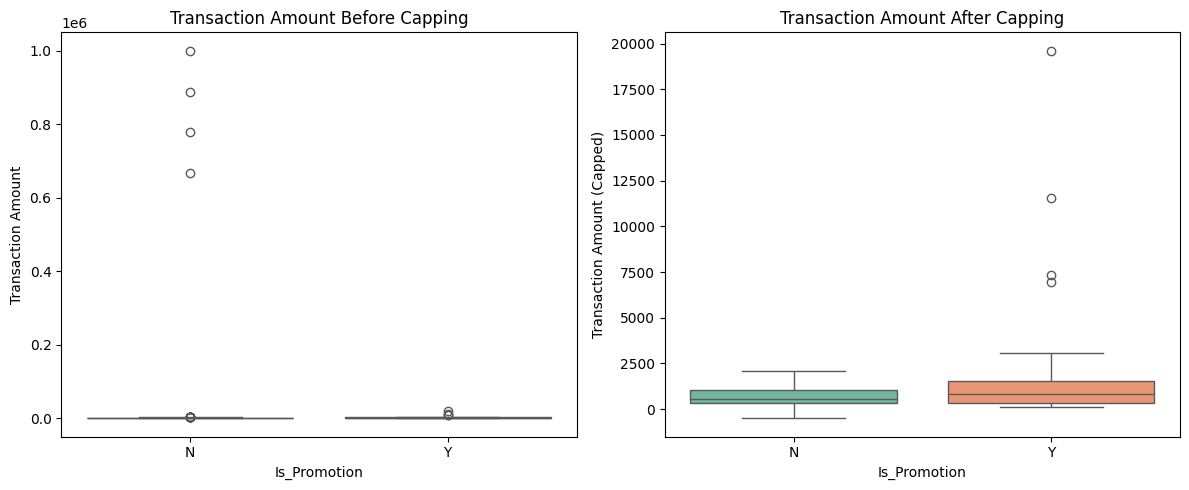

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# กราฟก่อน Capping
sns.boxplot(data=df1, x='Is_Promotion', y='Transaction_Amount', ax=axes[0], palette='Set2')
axes[0].set_title('Transaction Amount Before Capping')
axes[0].set_xlabel('Is_Promotion')
axes[0].set_ylabel('Transaction Amount')

# กราฟหลัง Capping
sns.boxplot(data=df1, x='Is_Promotion', y='Transaction_Amount_Clean', ax=axes[1], palette='Set2')
axes[1].set_title('Transaction Amount After Capping')
axes[1].set_xlabel('Is_Promotion')
axes[1].set_ylabel('Transaction Amount (Capped)')

plt.tight_layout()
plt.show()

# **Task 7 — Timeliness, Report และ Export**

**คำนวณ Load_Delay_Hours และกำหนด Late (เมื่อ > 24 ชั่วโมง)**

In [70]:
import pandas as pd
import numpy as np

# 1. โหลดข้อมูลดิบ
df_raw = pd.read_csv('/content/e_commerce_raw.csv')
df_clean = df_raw.copy()

# ==========================================
# Task 4: Uniqueness (ลบ Exact Duplicates ก่อน)
# ==========================================
df_clean = df_clean.drop_duplicates(keep='first').reset_index(drop=True)

# ==========================================
# Task 2: Completeness (เติมค่าว่าง Email & Province)
# ==========================================
df_clean['Customer_Email_Was_Missing'] = df_clean['Customer_Email'].isna()
df_clean['Province_Was_Missing'] = df_clean['Province'].isna()

df_clean['Customer_Email'] = df_clean.apply(
    lambda row: f"unknown_{row['Customer_ID']}@unknown.local" if pd.isna(row['Customer_Email']) else row['Customer_Email'],
    axis=1
)
df_clean['Province'] = df_clean['Province'].fillna('Unknown')

# ==========================================
# Task 3 & 7: Parse & Clean Order Date (ป้องกันวันที่เป็น NaN)
# ==========================================
def parse_and_clean_date(row):
    date_str = str(row['Order_Date']).strip()
    load_ts_str = str(row['Load_Timestamp']).strip()
    load_dt = pd.to_datetime(load_ts_str, errors='coerce')

    # 1) ตรวจสอบรูปแบบ YYYY-MM-DD
    try:
        dt = pd.to_datetime(date_str, format='%Y-%m-%d', errors='raise')
        return dt, 'ISO_YYYY-MM-DD', False
    except:
        pass

    # 2) ตรวจสอบรูปแบบ DD/MM/YYYY และ MM/DD/YYYY
    dt_dayfirst, dt_monthfirst = None, None
    try:
        dt_dayfirst = pd.to_datetime(date_str, format='%d/%m/%Y', errors='raise')
    except:
        pass
    try:
        dt_monthfirst = pd.to_datetime(date_str, format='%m/%d/%Y', errors='raise')
    except:
        pass

    # แก้ปัญหาความกำกวมโดยเทียบเดือนกับ Load_Timestamp
    if dt_dayfirst is not None and dt_monthfirst is not None:
        if pd.notna(load_dt) and dt_dayfirst.month == load_dt.month:
            return dt_dayfirst, 'Parsed_DD/MM/YYYY', False
        elif pd.notna(load_dt) and dt_monthfirst.month == load_dt.month:
            return dt_monthfirst, 'Parsed_MM/DD/YYYY', False
        else:
            return dt_dayfirst, 'Parsed_DD/MM/YYYY_Default', False
    elif dt_dayfirst is not None:
        return dt_dayfirst, 'Parsed_DD/MM/YYYY', False
    elif dt_monthfirst is not None:
        return dt_monthfirst, 'Parsed_MM/DD/YYYY', False

    # 3) หากอ่านไม่ได้เลย -> Fallback ไปใช้ Load_Timestamp เพื่อไม่ให้เป็น NaN
    if pd.notna(load_dt):
        return load_dt, 'Fallback_LoadTimestamp', True
    else:
        return pd.NaT, 'Failed', True

# ประยุกต์ใช้งาน
date_results = df_clean.apply(parse_and_clean_date, axis=1)
df_clean['Order_Date_dt'] = [r[0] for r in date_results]
df_clean['Order_Date_Was_Imputed'] = [r[2] for r in date_results]

# คำนวณ Timeliness & Load_Delay_Hours
df_clean['Load_Timestamp_dt'] = pd.to_datetime(df_clean['Load_Timestamp'], errors='coerce')
df_clean['Load_Delay_Hours'] = (df_clean['Load_Timestamp_dt'] - df_clean['Order_Date_dt']).dt.total_seconds() / 3600.0
df_clean['Is_Late'] = df_clean['Load_Delay_Hours'] > 24.0
df_clean['Order_Date_Clean'] = df_clean['Order_Date_dt'].dt.strftime('%Y-%m-%d')

# ==========================================
# Task 3: Consistency (Gender & Payment_Method)
# ==========================================
gender_map = {
    'm': 'M', 'male': 'M', 'M': 'M', 'MALE': 'M', 'Male': 'M',
    'f': 'F', 'female': 'F', 'F': 'F', 'FEMALE': 'F', 'Female': 'F'
}
df_clean['Gender'] = df_clean['Gender'].astype(str).str.strip().map(gender_map).fillna('Unknown')

payment_map = {
    'credit card': 'Credit Card', 'cc': 'Credit Card', 'card': 'Credit Card',
    'promptpay': 'PromptPay', 'pp': 'PromptPay', 'prompt pay': 'PromptPay',
    'cash on delivery': 'Cash on Delivery', 'cod': 'Cash on Delivery', 'cash': 'Cash on Delivery',
    'bank transfer': 'Bank Transfer', 'transfer': 'Bank Transfer', 'bank_transfer': 'Bank Transfer'
}
df_clean['Payment_Method'] = df_clean['Payment_Method'].astype(str).str.strip().str.lower().map(payment_map).fillna('Unknown')

# ==========================================
# Task 5: Validity & Accuracy
# ==========================================
df_clean['Quantity_Was_Invalid'] = ~df_clean['Quantity'].between(1, 20)
df_clean['Quantity_Clean'] = df_clean['Quantity'].clip(1, 20)

df_clean['Expected_Amount'] = (df_clean['Quantity_Clean'] * df_clean['Unit_Price'] * (1 - df_clean['Discount_Rate'])).round(2)
df_clean['Accuracy_Flag'] = (df_clean['Transaction_Amount'] - df_clean['Expected_Amount']).abs() > 1.0

status_map = {
    'Completed': 'Completed', 'done': 'Completed',
    'Processing': 'Processing',
    'Cancelled': 'Cancelled', 'Cancel': 'Cancelled',
    'Returned': 'Returned'
}
df_clean['Order_Status_Clean'] = df_clean['Order_Status'].astype(str).str.strip().map(status_map).fillna('Unknown')
valid_statuses = {'Completed', 'Processing', 'Cancelled', 'Returned'}
df_clean['Order_Status_Is_Invalid'] = ~df_clean['Order_Status_Clean'].isin(valid_statuses)

# ==========================================
# Task 6: Outliers (IQR Capping)
# ==========================================
non_promo = df_clean[df_clean['Is_Promotion'] != 'Y']['Transaction_Amount']
q1 = non_promo.quantile(0.25)
q3 = non_promo.quantile(0.75)
iqr = q3 - q1
upper_b = q3 + 1.5 * iqr
lower_b = q1 - 1.5 * iqr

df_clean['Outlier_Flag_Before_Capping'] = (df_clean['Is_Promotion'] != 'Y') & (
    (df_clean['Transaction_Amount'] < lower_b) | (df_clean['Transaction_Amount'] > upper_b)
)

df_clean['Transaction_Amount_Clean'] = df_clean['Transaction_Amount']
mask_non_promo = df_clean['Is_Promotion'] != 'Y'
df_clean.loc[mask_non_promo, 'Transaction_Amount_Clean'] = df_clean.loc[mask_non_promo, 'Transaction_Amount'].clip(lower_b, upper_b)

# ==========================================
# คัดเลือกคอลัมน์ + Export
# ==========================================
cols_export = [
    'Transaction_ID', 'Customer_ID', 'Customer_Name', 'Customer_Email',
    'Gender', 'Province', 'Order_Date_Clean', 'Load_Timestamp',
    'Product_Category', 'Quantity_Clean', 'Unit_Price', 'Discount_Rate',
    'Transaction_Amount_Clean', 'Expected_Amount', 'Payment_Method',
    'Order_Status_Clean', 'Is_Promotion', 'Load_Delay_Hours', 'Is_Late',
    'Quantity_Was_Invalid', 'Accuracy_Flag', 'Order_Status_Is_Invalid',
    'Outlier_Flag_Before_Capping', 'Order_Date_Was_Imputed'
]

df_export = df_clean[cols_export].rename(columns={
    'Order_Date_Clean': 'Order_Date',
    'Quantity_Clean': 'Quantity',
    'Transaction_Amount_Clean': 'Transaction_Amount',
    'Order_Status_Clean': 'Order_Status'
})

# Export ไฟล์
df_export.to_csv('e_commerce_clean.csv', index=False, encoding='utf-8-sig')

print("--- ตรวจสอบ Missing Values หลังแก้ ---")
print(df_export.isna().sum())
print("\nExport ไฟล์ e_commerce_clean.csv เรียบร้อยแล้ว! ( Missing Values เป็น 0 ทุกคอลัมน์)")

--- ตรวจสอบ Missing Values หลังแก้ ---
Transaction_ID                 0
Customer_ID                    0
Customer_Name                  0
Customer_Email                 0
Gender                         0
Province                       0
Order_Date                     0
Load_Timestamp                 0
Product_Category               0
Quantity                       0
Unit_Price                     0
Discount_Rate                  0
Transaction_Amount             0
Expected_Amount                0
Payment_Method                 0
Order_Status                   0
Is_Promotion                   0
Load_Delay_Hours               0
Is_Late                        0
Quantity_Was_Invalid           0
Accuracy_Flag                  0
Order_Status_Is_Invalid        0
Outlier_Flag_Before_Capping    0
Order_Date_Was_Imputed         0
dtype: int64

Export ไฟล์ e_commerce_clean.csv เรียบร้อยแล้ว! ( Missing Values เป็น 0 ทุกคอลัมน์)
